In [1]:
# Importing setup file
from setup import *

# Link directory to save figures
out_path = "output/p34"
os.makedirs(out_path, exist_ok=True)

## Loading Dataset

In [2]:
translationDataset = load_file(translation=True, filePath=BASE_DIR/"data/vast_english_french.txt")

### Hyperparameters Independent to Dataset

In [3]:
max_length = 100 # Max sentence length that shouldn't be exceeded in the dataset
batch_size = 1
epochs = 100

## Helper Functions

In [4]:
def forward_pass(model, input_tensor, target_tensor, criterion, output_size):
    # Flattening dimensions to allow passing into criterion
    output = model(input_tensor, target_tensor[:, :-1])
    loss = criterion(output.reshape(-1, output_size), target_tensor[:, 1:].reshape(-1))

    return loss

In [5]:
def train(model, input_tensor, target_tensor, optimizer, criterion, output_size):
    optimizer.zero_grad()
    loss = forward_pass(model, input_tensor, target_tensor, criterion, output_size)
    loss.backward()
    optimizer.step()

    return loss.item()

In [6]:
def train_model(model, train_loader, val_loader, output_size):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0) # Ignoring the SOS token

    #Initializing loss variables
    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):
        # Training Loop
        model.train()
        epoch_train_loss = 0.0

        for train_x, train_y in train_loader:
            X_train = train_x.to(device)
            Y_train = train_y.to(device)

            loss = train(model, input_tensor=X_train, target_tensor=Y_train, optimizer=optimizer, criterion=criterion, output_size=output_size)
            epoch_train_loss += loss
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Loop
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for val_x, val_y in val_loader:
                X_val = val_x.to(device)
                Y_val = val_y.to(device)

                loss = forward_pass(model, input_tensor=X_val, target_tensor=Y_val, criterion=criterion, output_size=output_size)
                epoch_val_loss += loss.item()
            
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}:\n Loss: {avg_train_loss:.3f}, Validation Loss: {avg_val_loss:.3f}')

    train_time = time.time() - start_time

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'train_time': train_time,
    }

In [7]:
def eval_show_eg(model, val_loader, idx_to_chars, output_size, n_eg=5):
    model.eval()

    exact_matches = 0.0
    total_bleu_score = 0.0
    chencherry = SmoothingFunction()

    print("\n")
    print("="*40)
    print("Generating Validation Examples")
    print("="*40)

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor.to(device)
            target_tensor = target_tensor.to(device)

            # Decoding
            encoder_embedded = model.encoder_embedding(input_tensor)
            encoder_pos_embedded = model.encoder_pos_encoder(encoder_embedded)
            encoder_output = model.transformer_encoder(encoder_pos_embedded)

            # Starting with the SOS token
            decoder_input = torch.tensor([[SOS_token]], device=device)
            predicted_id = []

            for _ in range(max_length):
                decoder_embedded = model.decoder_embedding(decoder_input)
                decoder_pos_embedded = model.decoder_pos_encoder(decoder_embedded)
                decoder_output = model.transformer_decoder(decoder_pos_embedded, encoder_output)
                output = model.fc(decoder_output[:, -1, :])

                _, topi = output.topk(1)
                idx = topi.item()
                predicted_id.append(idx)
                
                decoder_input = torch.cat([decoder_input, torch.tensor([[idx]], device=device)], dim=1)

                if idx == EOS_token:
                    break
            
            # Converting to strings
            inp_string = ''.join([idx_to_chars[id.item()] for id in input_tensor[0] if id.item() not in (SOS_token, EOS_token)])
            tgt_string = ''.join([idx_to_chars[id.item()] for id in target_tensor[0] if id.item() not in (SOS_token, EOS_token)])
            predicted_string = ''.join([idx_to_chars[id] for id in predicted_id if id not in (SOS_token, EOS_token)])
            
            # Traditional Sequence Accuracy
            if predicted_string == tgt_string:
                exact_matches += 1

            # BLEU Score
            ref_tokens = [list(tgt_string)]
            candidate_tokens = list(predicted_string)
            
            bleu = sentence_bleu(ref_tokens, candidate_tokens, smoothing_function=chencherry.method1)
            total_bleu_score += bleu

            # Generating text samples
            if i < n_eg:
                match_status = "PASS" if predicted_string == tgt_string else "FAIL"
                print(f'Input: {inp_string:<12} |   Target: {tgt_string:<12}    |   Predicted: {predicted_string:<12}   |   Match: {match_status:<4}')
        
        final_acc = exact_matches / len(val_loader)
        avg_bleu = total_bleu_score / len(val_loader)

    return final_acc, avg_bleu
            

In [8]:
def print_results(results):
    for metric_name, key, fmt in [
    ("Final Train Loss",    "final_train_loss", ".4f"),
    ("Final Val Loss",      "final_val_loss",   ".4f"),
    ("Traditional Sequence Accuracy", "seq_acc", ".4f"),
    ("Validation BLEU-4 Score",   "avg_bleu",   ".4f"),
    ("Train Time (s)",      "train_time",       ".2f"),
    ]:
        print("\n")
        print(f'{metric_name}')
        print("="*15)
        for config in transformer_configs:
            nlayers = config['num_layers']
            nheads = config['nhead']

            value = results[nlayers][nheads][key]
            
            try:
                print(f'Layers: {nlayers}, Heads: {nheads} --> Value: {value:{fmt}}')
            except (ValueError, TypeError):
                print(f'Layers: {nlayers}, Heads: {nheads} --> Value: {value}')

## Main Functions

In [9]:
def eng2Fra():
    part3 = {}

    # Building vocab
    unique_chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=True, dataset=translationDataset)

    # Dependent Hyperparameters
    input_size = len(chars_to_idx)
    output_size = input_size

    for config in transformer_configs:
        nlayers = config["num_layers"]
        nheads = config["nhead"]

        #Instantiating required model variables
        model = translationTransformer(input_size=input_size, hidden_size=hidden_size, output_size=output_size, num_layers=nlayers, nhead=nheads).to(device)
        dataset = TranslationDataset(dataset=translationDataset, chars_to_idx=chars_to_idx)
        train_loader, val_loader = build_loaders(dataset=dataset, batch_size=batch_size)

        # Initializing results dictionary
        if nlayers not in part3:
            part3[nlayers] = {}
        part3[nlayers][nheads] = {}

        print("\n")
        print("="*50)
        print(f'Number of Layers: {nlayers}   |   Number of heads: {nheads}')
        print("="*50)

        metrics = train_model(model, train_loader=train_loader, val_loader=val_loader, output_size=output_size)
        seq_acc, avg_bleu = eval_show_eg(model=model, val_loader=val_loader, idx_to_chars=idx_to_chars, output_size=output_size)

        part3[nlayers][nheads] = {
            **metrics,
            "seq_acc":  seq_acc,
            "avg_bleu": avg_bleu,
        }

        plot_loss(train_losses=part3[nlayers][nheads]["train_losses"], val_losses=part3[nlayers][nheads]["val_losses"],
                  title=f'English-to-French Translation Trained with Transformer Model (Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/translationTransformer_eng2fra_layers{nlayers}_head{nheads}_evalCurve')
    
    print("English-to-French Translation Results:")
    print_results(part3)

In [10]:
def fra2Eng():
    part4 = {}

    # Reversing the dataset for French-to-English 
    translationDataset_reversed = [(fra, eng) for eng, fra in translationDataset]

    # Rebuilding vocab
    unique_chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=True, dataset=translationDataset_reversed)

    # Dependent Hyperparameters
    input_size = len(chars_to_idx)
    output_size = input_size

    for config in transformer_configs:
        nlayers = config["num_layers"]
        nheads = config["nhead"]

        #Instantiating required model variables
        model = translationTransformer(input_size=input_size, hidden_size=hidden_size, output_size=output_size, num_layers=nlayers, nhead=nheads).to(device)
        dataset = TranslationDataset(dataset=translationDataset_reversed, chars_to_idx=chars_to_idx)
        train_loader, val_loader = build_loaders(dataset=dataset, batch_size=batch_size)

        # Initializing results dictionary
        if nlayers not in part4:
            part4[nlayers] = {}
        part4[nlayers][nheads] = {}

        print("\n")
        print("="*50)
        print(f'Number of Layers: {nlayers}   |   Number of heads: {nheads}')
        print("="*50)

        metrics = train_model(model, train_loader=train_loader, val_loader=val_loader, output_size=output_size)
        seq_acc, avg_bleu = eval_show_eg(model=model, val_loader=val_loader, idx_to_chars=idx_to_chars, output_size=output_size)

        part4[nlayers][nheads] = {
            **metrics,
            "seq_acc":  seq_acc,
            "avg_bleu": avg_bleu,
        }

        plot_loss(train_losses=part4[nlayers][nheads]["train_losses"], val_losses=part4[nlayers][nheads]["val_losses"],
                  title=f'French-to-English Translation Trained with Transformer Model (Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/translationTransformer_fra2eng_layers{nlayers}_head{nheads}_evalCurve')

    print("French-to-English Translation Results:")    
    print_results(part4)

PROBLEM 3: English-to-French Translation | 6 Transformer Configurations


Number of Layers: 1   |   Number of heads: 2
Epoch 10:
 Loss: 1.856, Validation Loss: 1.958
Epoch 20:
 Loss: 1.473, Validation Loss: 1.799
Epoch 30:
 Loss: 1.188, Validation Loss: 1.765
Epoch 40:
 Loss: 0.940, Validation Loss: 1.863
Epoch 50:
 Loss: 0.763, Validation Loss: 1.970
Epoch 60:
 Loss: 0.626, Validation Loss: 2.082
Epoch 70:
 Loss: 0.507, Validation Loss: 2.186
Epoch 80:
 Loss: 0.421, Validation Loss: 2.375
Epoch 90:
 Loss: 0.356, Validation Loss: 2.428
Epoch 100:
 Loss: 0.311, Validation Loss: 2.480


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: ime peint les l'écoloit les à en lest mon à le let la moudicarisies mondisies mousss ere mouxis hech   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted: imlle travaisité la cafête   |   M

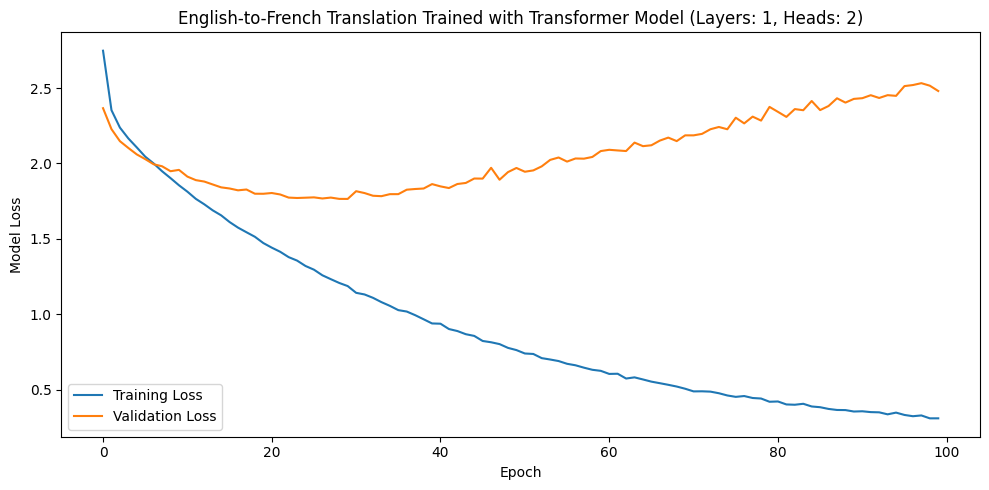



Number of Layers: 1   |   Number of heads: 4
Epoch 10:
 Loss: 1.824, Validation Loss: 1.899
Epoch 20:
 Loss: 1.403, Validation Loss: 1.790
Epoch 30:
 Loss: 1.080, Validation Loss: 1.790
Epoch 40:
 Loss: 0.832, Validation Loss: 1.875
Epoch 50:
 Loss: 0.637, Validation Loss: 2.024
Epoch 60:
 Loss: 0.492, Validation Loss: 2.169
Epoch 70:
 Loss: 0.392, Validation Loss: 2.327
Epoch 80:
 Loss: 0.317, Validation Loss: 2.441
Epoch 90:
 Loss: 0.265, Validation Loss: 2.528
Epoch 100:
 Loss: 0.228, Validation Loss: 2.654


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: ous alit des délument à lui la mupuie lait des aujoud'é   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted: e travaille es congle emain   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux une grande part de gâteau au chocolat  

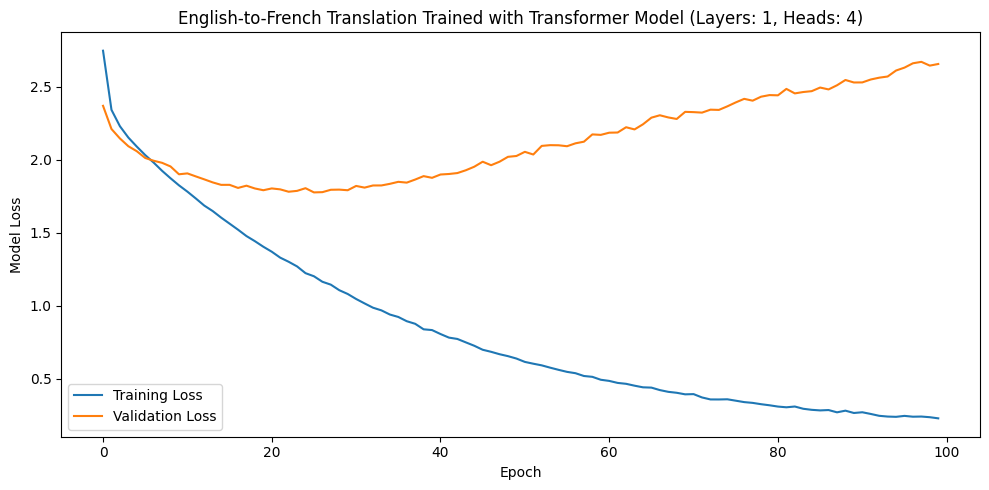



Number of Layers: 2   |   Number of heads: 2
Epoch 10:
 Loss: 1.700, Validation Loss: 1.823
Epoch 20:
 Loss: 1.153, Validation Loss: 1.761
Epoch 30:
 Loss: 0.774, Validation Loss: 1.864
Epoch 40:
 Loss: 0.523, Validation Loss: 2.043
Epoch 50:
 Loss: 0.351, Validation Loss: 2.315
Epoch 60:
 Loss: 0.263, Validation Loss: 2.504
Epoch 70:
 Loss: 0.210, Validation Loss: 2.554
Epoch 80:
 Loss: 0.169, Validation Loss: 2.694
Epoch 90:
 Loss: 0.132, Validation Loss: 2.853
Epoch 100:
 Loss: 0.125, Validation Loss: 2.865


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted:  prain lisé des domancrit les de la matidîcous   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted: e trend la c ent dans ctoffêt   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux une grande part de gâteau au chocolat    |   P

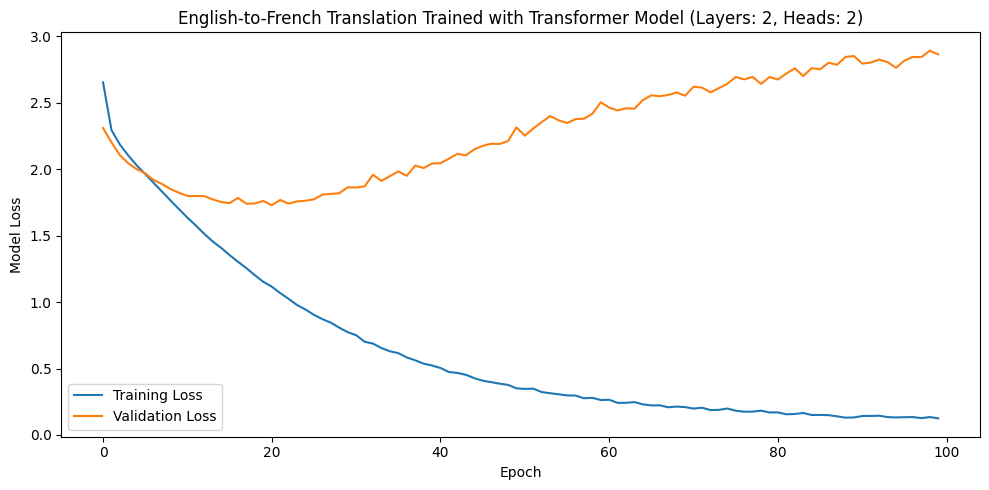



Number of Layers: 2   |   Number of heads: 4
Epoch 10:
 Loss: 1.693, Validation Loss: 1.863
Epoch 20:
 Loss: 1.108, Validation Loss: 1.760
Epoch 30:
 Loss: 0.702, Validation Loss: 1.944
Epoch 40:
 Loss: 0.453, Validation Loss: 2.198
Epoch 50:
 Loss: 0.296, Validation Loss: 2.449
Epoch 60:
 Loss: 0.215, Validation Loss: 2.601
Epoch 70:
 Loss: 0.171, Validation Loss: 2.776
Epoch 80:
 Loss: 0.134, Validation Loss: 2.936
Epoch 90:
 Loss: 0.107, Validation Loss: 2.950
Epoch 100:
 Loss: 0.102, Validation Loss: 3.128


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: 'ai peu des roiticle musit un grait un derau mitit   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted: e latcnons traparle bare   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux une grande part de gâteau au chocolat    |   Pr

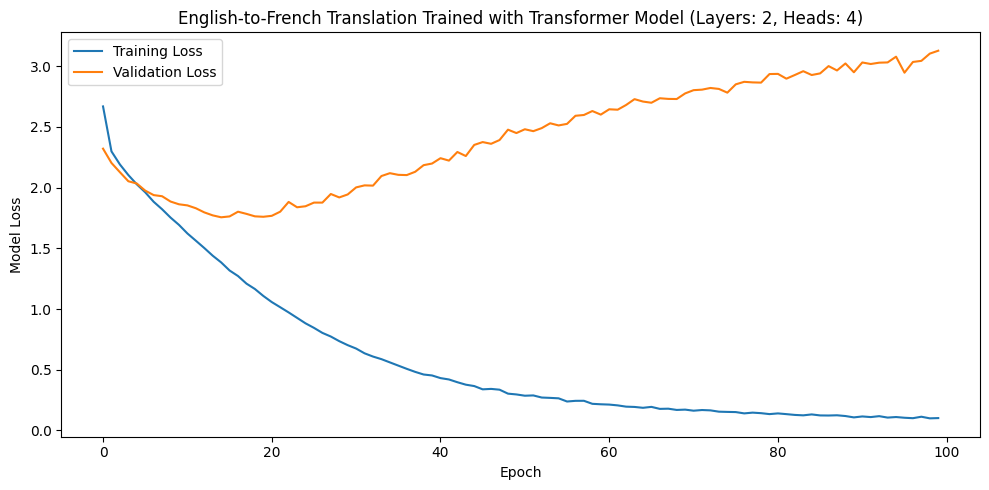



Number of Layers: 4   |   Number of heads: 2
Epoch 10:
 Loss: 1.722, Validation Loss: 1.812
Epoch 20:
 Loss: 1.154, Validation Loss: 1.670
Epoch 30:
 Loss: 0.696, Validation Loss: 1.848
Epoch 40:
 Loss: 0.410, Validation Loss: 2.129
Epoch 50:
 Loss: 0.253, Validation Loss: 2.353
Epoch 60:
 Loss: 0.168, Validation Loss: 2.606
Epoch 70:
 Loss: 0.139, Validation Loss: 2.766
Epoch 80:
 Loss: 0.111, Validation Loss: 2.861
Epoch 90:
 Loss: 0.092, Validation Loss: 2.995
Epoch 100:
 Loss: 0.085, Validation Loss: 3.043


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: u pela est trouit des monde milix pre   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted: ur le chaué un voiture   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux une grande part de gâteau au chocolat    |   Predicted: e cart

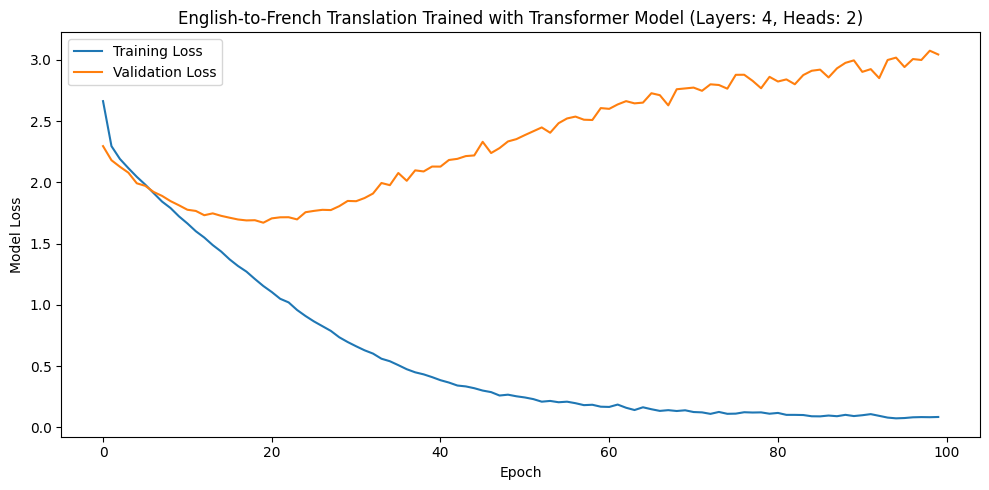



Number of Layers: 4   |   Number of heads: 4
Epoch 10:
 Loss: 1.728, Validation Loss: 1.830
Epoch 20:
 Loss: 1.142, Validation Loss: 1.722
Epoch 30:
 Loss: 0.675, Validation Loss: 1.890
Epoch 40:
 Loss: 0.383, Validation Loss: 2.168
Epoch 50:
 Loss: 0.234, Validation Loss: 2.428
Epoch 60:
 Loss: 0.165, Validation Loss: 2.664
Epoch 70:
 Loss: 0.124, Validation Loss: 2.853
Epoch 80:
 Loss: 0.105, Validation Loss: 3.008
Epoch 90:
 Loss: 0.093, Validation Loss: 3.072
Epoch 100:
 Loss: 0.068, Validation Loss: 3.137


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: e troit aions lemat cioyable endes mur en à codert   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted:  regarle fant bleau   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux une grande part de gâteau au chocolat    |   Predict

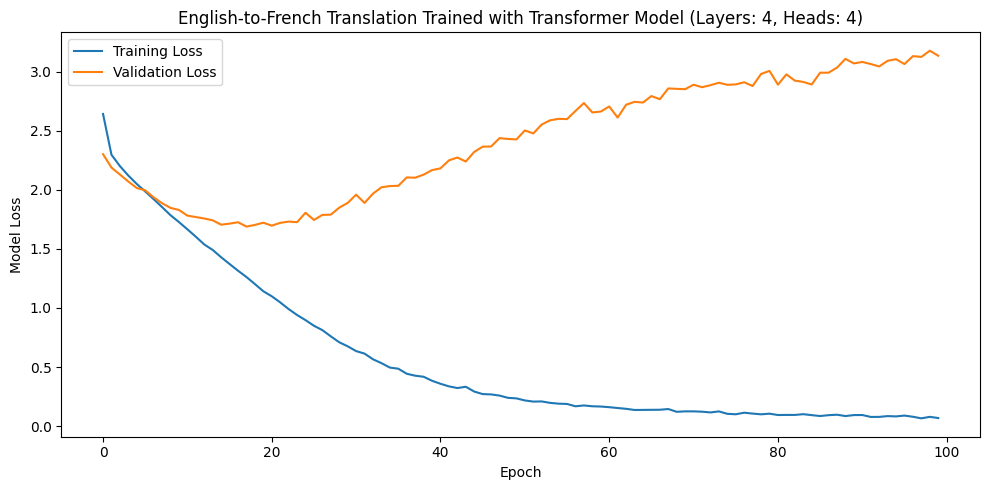

English-to-French Translation Results:


Final Train Loss
Layers: 1, Heads: 2 --> Value: 0.3112
Layers: 1, Heads: 4 --> Value: 0.2280
Layers: 2, Heads: 2 --> Value: 0.1251
Layers: 2, Heads: 4 --> Value: 0.1017
Layers: 4, Heads: 2 --> Value: 0.0845
Layers: 4, Heads: 4 --> Value: 0.0678


Final Val Loss
Layers: 1, Heads: 2 --> Value: 2.4803
Layers: 1, Heads: 4 --> Value: 2.6544
Layers: 2, Heads: 2 --> Value: 2.8646
Layers: 2, Heads: 4 --> Value: 3.1277
Layers: 4, Heads: 2 --> Value: 3.0434
Layers: 4, Heads: 4 --> Value: 3.1368


Traditional Sequence Accuracy
Layers: 1, Heads: 2 --> Value: 0.0000
Layers: 1, Heads: 4 --> Value: 0.0000
Layers: 2, Heads: 2 --> Value: 0.0000
Layers: 2, Heads: 4 --> Value: 0.0000
Layers: 4, Heads: 2 --> Value: 0.0000
Layers: 4, Heads: 4 --> Value: 0.0000


Validation BLEU-4 Score
Layers: 1, Heads: 2 --> Value: 0.1909
Layers: 1, Heads: 4 --> Value: 0.1984
Layers: 2, Heads: 2 --> Value: 0.1745
Layers: 2, Heads: 4 --> Value: 0.1688
Layers: 4, Heads: 2 --> Value: 

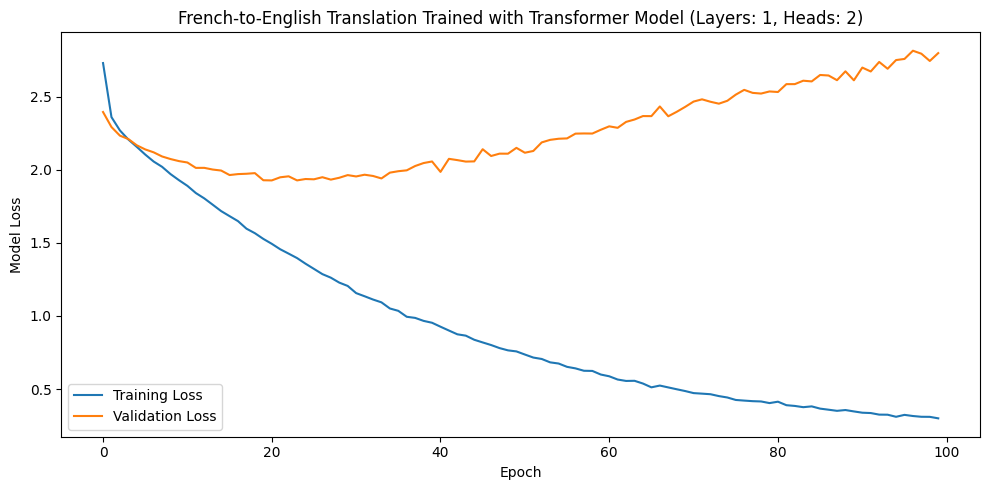



Number of Layers: 1   |   Number of heads: 4
Epoch 10:
 Loss: 1.872, Validation Loss: 2.030
Epoch 20:
 Loss: 1.434, Validation Loss: 1.930
Epoch 30:
 Loss: 1.086, Validation Loss: 2.012
Epoch 40:
 Loss: 0.806, Validation Loss: 2.146
Epoch 50:
 Loss: 0.610, Validation Loss: 2.294
Epoch 60:
 Loss: 0.464, Validation Loss: 2.494
Epoch 70:
 Loss: 0.364, Validation Loss: 2.664
Epoch 80:
 Loss: 0.306, Validation Loss: 2.804
Epoch 90:
 Loss: 0.239, Validation Loss: 2.902
Epoch 100:
 Loss: 0.205, Validation Loss: 3.030


Generating Validation Examples
Input: Il répond immédiatement à tous les e-mails des clients |   Target: He replies to all customer emails immediately    |   Predicted: eneed to rum elatient aicestiong evelient mals   |   Match: FAIL
Input: Nous travaillons au bureau |   Target: We work in the office    |   Predicted: y wilun a buysoment butail ating   |   Match: FAIL
Input: Je veux une grande part de gâteau au chocolat |   Target: I want a large slice of chocolate cake    | 

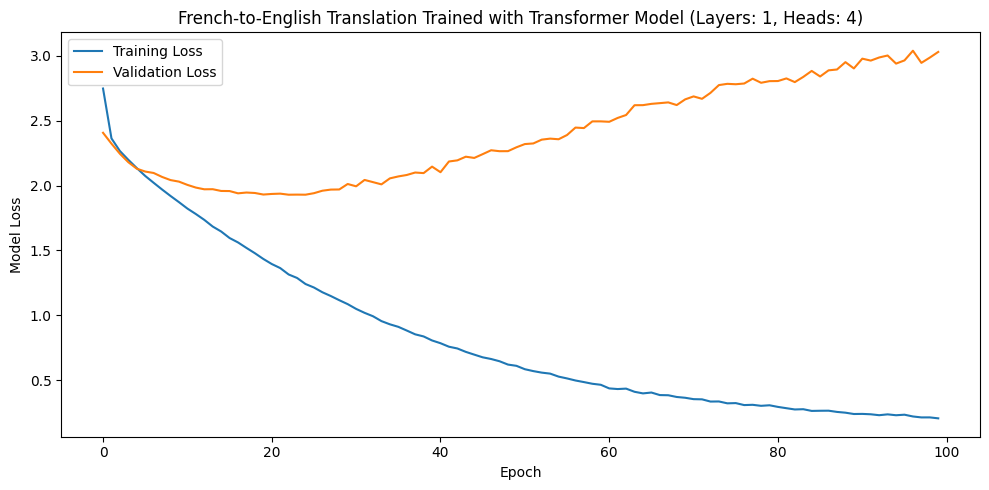



Number of Layers: 2   |   Number of heads: 2
Epoch 10:
 Loss: 1.747, Validation Loss: 1.953
Epoch 20:
 Loss: 1.196, Validation Loss: 1.907
Epoch 30:
 Loss: 0.783, Validation Loss: 2.129
Epoch 40:
 Loss: 0.518, Validation Loss: 2.248
Epoch 50:
 Loss: 0.363, Validation Loss: 2.537
Epoch 60:
 Loss: 0.259, Validation Loss: 2.677
Epoch 70:
 Loss: 0.218, Validation Loss: 2.847
Epoch 80:
 Loss: 0.165, Validation Loss: 2.990
Epoch 90:
 Loss: 0.151, Validation Loss: 3.109
Epoch 100:
 Loss: 0.138, Validation Loss: 3.115


Generating Validation Examples
Input: Il répond immédiatement à tous les e-mails des clients |   Target: He replies to all customer emails immediately    |   Predicted: e aswers the maint echis amily sumerning the lon   |   Match: FAIL
Input: Nous travaillons au bureau |   Target: We work in the office    |   Predicted:                |   Match: FAIL
Input: Je veux une grande part de gâteau au chocolat |   Target: I want a large slice of chocolate cake    |   Predicted:  want

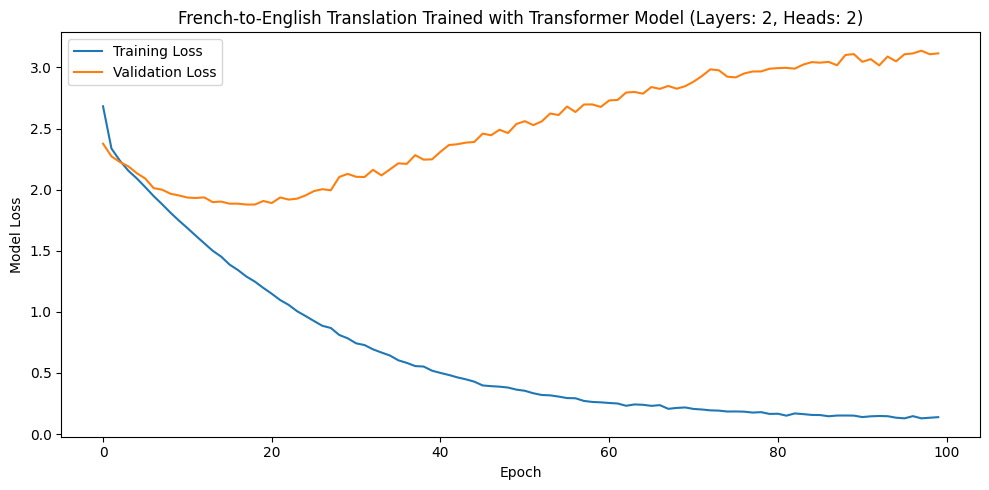



Number of Layers: 2   |   Number of heads: 4
Epoch 10:
 Loss: 1.725, Validation Loss: 1.944
Epoch 20:
 Loss: 1.115, Validation Loss: 1.902
Epoch 30:
 Loss: 0.682, Validation Loss: 2.094
Epoch 40:
 Loss: 0.424, Validation Loss: 2.394
Epoch 50:
 Loss: 0.275, Validation Loss: 2.681
Epoch 60:
 Loss: 0.205, Validation Loss: 2.801
Epoch 70:
 Loss: 0.165, Validation Loss: 3.026
Epoch 80:
 Loss: 0.129, Validation Loss: 3.091
Epoch 90:
 Loss: 0.114, Validation Loss: 3.222
Epoch 100:
 Loss: 0.105, Validation Loss: 3.232


Generating Validation Examples
Input: Il répond immédiatement à tous les e-mails des clients |   Target: He replies to all customer emails immediately    |   Predicted: ly stent mathemall mow sthekeys dentsion stalll   |   Match: FAIL
Input: Nous travaillons au bureau |   Target: We work in the office    |   Predicted: e works arin a boar   |   Match: FAIL
Input: Je veux une grande part de gâteau au chocolat |   Target: I want a large slice of chocolate cake    |   Predicted:

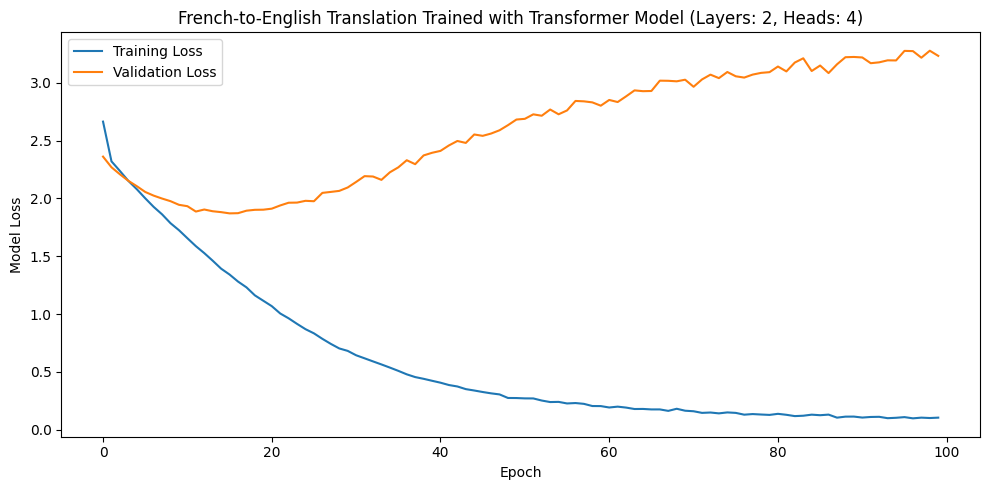



Number of Layers: 4   |   Number of heads: 2
Epoch 10:
 Loss: 1.773, Validation Loss: 2.002
Epoch 20:
 Loss: 1.225, Validation Loss: 1.819
Epoch 30:
 Loss: 0.739, Validation Loss: 1.973
Epoch 40:
 Loss: 0.422, Validation Loss: 2.221
Epoch 50:
 Loss: 0.264, Validation Loss: 2.518
Epoch 60:
 Loss: 0.179, Validation Loss: 2.774
Epoch 70:
 Loss: 0.142, Validation Loss: 2.863
Epoch 80:
 Loss: 0.119, Validation Loss: 3.025
Epoch 90:
 Loss: 0.105, Validation Loss: 3.175
Epoch 100:
 Loss: 0.086, Validation Loss: 3.254


Generating Validation Examples
Input: Il répond immédiatement à tous les e-mails des clients |   Target: He replies to all customer emails immediately    |   Predicted:  post my climbs the intreques   |   Match: FAIL
Input: Nous travaillons au bureau |   Target: We work in the office    |   Predicted:  want tsha moundior   |   Match: FAIL
Input: Je veux une grande part de gâteau au chocolat |   Target: I want a large slice of chocolate cake    |   Predicted: e ant a coatesour

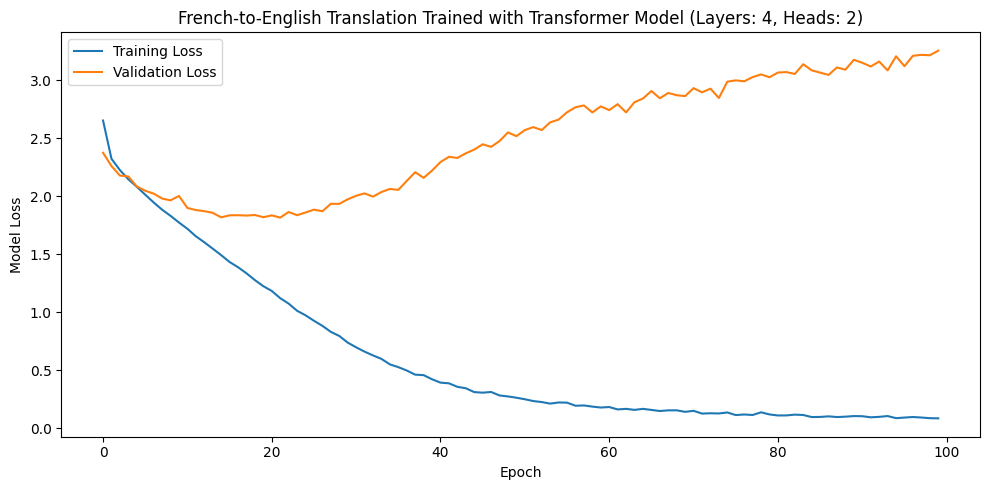



Number of Layers: 4   |   Number of heads: 4
Epoch 10:
 Loss: 1.743, Validation Loss: 1.932
Epoch 20:
 Loss: 1.146, Validation Loss: 1.876
Epoch 30:
 Loss: 0.659, Validation Loss: 2.074
Epoch 40:
 Loss: 0.357, Validation Loss: 2.442
Epoch 50:
 Loss: 0.225, Validation Loss: 2.688
Epoch 60:
 Loss: 0.155, Validation Loss: 2.965
Epoch 70:
 Loss: 0.127, Validation Loss: 3.127
Epoch 80:
 Loss: 0.102, Validation Loss: 3.240
Epoch 90:
 Loss: 0.089, Validation Loss: 3.216
Epoch 100:
 Loss: 0.081, Validation Loss: 3.373


Generating Validation Examples
Input: Il répond immédiatement à tous les e-mails des clients |   Target: He replies to all customer emails immediately    |   Predicted: wantchien to aless iar t pevery ambstenterntinsh   |   Match: FAIL
Input: Nous travaillons au bureau |   Target: We work in the office    |   Predicted: waill caroun a dddle   |   Match: FAIL
Input: Je veux une grande part de gâteau au chocolat |   Target: I want a large slice of chocolate cake    |   Predicte

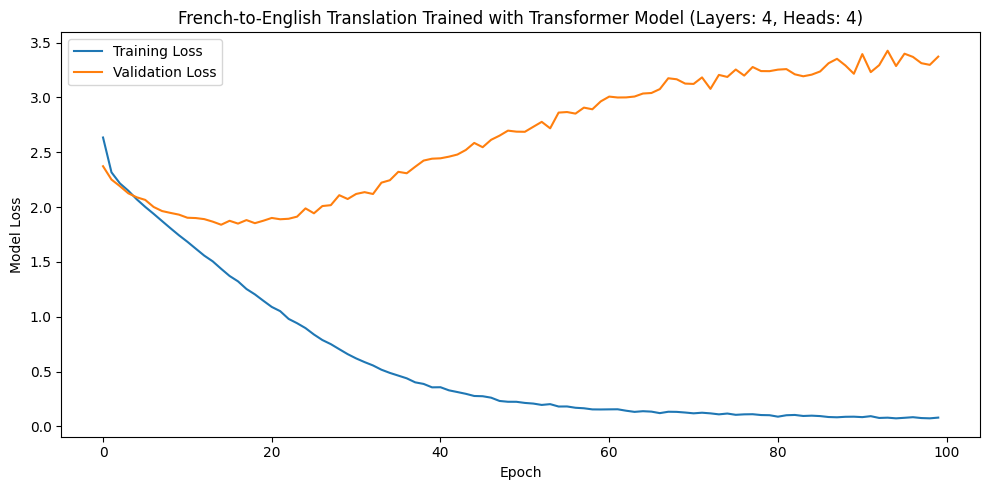

French-to-English Translation Results:


Final Train Loss
Layers: 1, Heads: 2 --> Value: 0.3002
Layers: 1, Heads: 4 --> Value: 0.2053
Layers: 2, Heads: 2 --> Value: 0.1382
Layers: 2, Heads: 4 --> Value: 0.1053
Layers: 4, Heads: 2 --> Value: 0.0858
Layers: 4, Heads: 4 --> Value: 0.0805


Final Val Loss
Layers: 1, Heads: 2 --> Value: 2.7972
Layers: 1, Heads: 4 --> Value: 3.0296
Layers: 2, Heads: 2 --> Value: 3.1155
Layers: 2, Heads: 4 --> Value: 3.2315
Layers: 4, Heads: 2 --> Value: 3.2539
Layers: 4, Heads: 4 --> Value: 3.3729


Traditional Sequence Accuracy
Layers: 1, Heads: 2 --> Value: 0.0000
Layers: 1, Heads: 4 --> Value: 0.0000
Layers: 2, Heads: 2 --> Value: 0.0000
Layers: 2, Heads: 4 --> Value: 0.0000
Layers: 4, Heads: 2 --> Value: 0.0000
Layers: 4, Heads: 4 --> Value: 0.0000


Validation BLEU-4 Score
Layers: 1, Heads: 2 --> Value: 0.1835
Layers: 1, Heads: 4 --> Value: 0.1551
Layers: 2, Heads: 2 --> Value: 0.1585
Layers: 2, Heads: 4 --> Value: 0.1515
Layers: 4, Heads: 2 --> Value: 

In [11]:
print("=" * 70)
print("PROBLEM 3: English-to-French Translation | 6 Transformer Configurations")
print("=" * 70)

eng2Fra()

print("=" * 70)
print("PROBLEM 4: French-to-English Translation | 6 Transformer Configurations")
print("=" * 70)

fra2Eng()